In [ ]:
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
def ladderops(ns):
    a = np.zeros((ns, ns), dtype=complex)

    for n in range(ns - 1):
        a[n, n + 1] = np.sqrt(n + 1) 
        
    ad = a.T                           
    return a, ad

In [ ]:
def HamiltonianHO(ns, omega, llambda):
    a, ad = ladderops(ns)

    phi = (a + ad) / np.sqrt(2.0 * omega)
    pi  = 1j * np.sqrt(omega / 2.0) * (ad - a)

    H = 0.5 * (pi @ pi + phi @ phi) + (llambda / 24.0) * (phi @ phi @ phi @ phi)

    H = 0.5 * (H + H.conj().T)
    return H

In [ ]:
def findPrecisionHO(ns, omega, llamda, E0ref):

    H = HamiltonianHO(ns, omega, llamda)

    evals = np.linalg.eig(H)[0]
    e0 = np.min(np.real(evals))

    return 100*np.abs((e0 - E0ref)/E0ref)

In [ ]:
def ComputeResultsHO(nqList, omegaList, llambda, E0ref):
    results = {}

    print(f"Computing HO results for llambda = {llambda}")
    print(f"Reference E0 = {E0ref}")

    for nq in nqList:
        ns = 2 ** nq
        print(f"Calculating for nQ = {nq} (ns = {ns})")

        data = np.empty((len(omegaList), 2), dtype=float)
        for i, omega in enumerate(omegaList):
            data[i, 0] = omega
            data[i, 1] = findPrecisionHO(ns, omega, llambda, E0ref)

        results[nq] = data

    return results

In [ ]:
def SingleSetResultsHO(resultsHO, nqList, scalar, llambda):
    plt.figure(figsize=(10, 6))

    for nq in nqList:
        data = resultsHO[nq]
        omega = data[:, 0]
        prec  = data[:, 1]

        omega_safe = np.maximum(omega, np.finfo(float).tiny)

        x_eff = scalar * np.sqrt((2.0 ** nq) / omega_safe)

        plt.semilogy(x_eff, prec, label=f"nQ = {nq}")

    plt.xlabel(f"effective phimax:({scalar} √(2^nQ)/w)")
    plt.ylabel("Precision (%)")
    plt.title(f"resultsHO llambda = {llambda} (HO Basis)")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [ ]:
E0 = 0.85974269044550901935596
omega_list = np.linspace(1,50, 1000)
nq_list = (3,4,5)
llambda = 32

resultsHO = ComputeResultsHO(nq_list, omega_list, llambda, E0)
SingleSetResultsHO(resultsHO, nq_list, scalar=1.4, llambda=llambda)
    
        


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# JLP Hamiltonian (0+1D HO digitisation via QFT-style Fourier matrix)
# -------------------------
def hamiltonian_jlp(ns: int, phi_max: float, omega: float):
    """
    Returns (H, phi_grid) where:
      - H is ns x ns Hermitian matrix for H = 1/2 (Pi^2 + omega^2 phi^2)
      - phi_grid is the sampled field values (length ns)
    """
    delta_phi = 2.0 * phi_max / (ns - 1)
    beta = np.arange(ns)
    phi = -phi_max + beta * delta_phi
    phi2 = np.diag(phi**2)

    kmax = np.pi / delta_phi
    delta_k = 2.0 * np.pi / (delta_phi * ns)
    betak = np.arange(ns)
    k = -kmax + betak * delta_k

    F = np.exp(-1j * np.outer(k, phi)) / np.sqrt(ns)

    pi_k2 = np.diag(k**2)
    pi_phi2 = F.conj().T @ pi_k2 @ F

    H = 0.5 * (pi_phi2 + omega**2 * phi2)
    H = 0.5 * (H + H.conj().T)
    return H, phi


# -------------------------
# Finite-difference Hamiltonian
# -------------------------
def hamiltonian_fd_corrected(ns: int, phi_max: float, omega: float):
    """
      H = 0.5 (phi2 + Piphi2) + 1/24 deltaPhi^2 MatrixPower[Piphi2, 4]

    with omega included in the potential term:
      0.5 * omega^2 * phi^2

    Returns (H, phi_grid).
    """
    delta_phi = 2.0 * phi_max / (ns - 1)
    beta = np.arange(ns)
    phi = -phi_max + beta * delta_phi
    phi2 = np.diag(phi**2)

    # Periodic finite-difference Laplacian / kinetic matrix
    lap = np.zeros((ns, ns), dtype=float)
    for i in range(ns):
        lap[i, i] = 2.0
        lap[i, (i + 1) % ns] = -1.0
        lap[(i - 1) % ns, i] = -1.0
    lap /= delta_phi**2

    Piphi2 = lap

    # Literal Mathematica translation
    H = 0.5 * (omega**2 * phi2 + Piphi2) + (delta_phi**2 / 24.0) * np.linalg.matrix_power(Piphi2, 4)

    H = 0.5 * (H + H.T)
    return H, phi


def find_precision(method: str, ns: int, phi_max: float, omega: float):
    """
    Returns relative % error for the lowest 5 eigenvalues vs exact HO levels.
    """
    if method == "JLP":
        H, _ = hamiltonian_jlp(ns, phi_max, omega)
    elif method == "FD":
        H, _ = hamiltonian_fd_corrected(ns, phi_max, omega)
    else:
        raise ValueError("method must be 'JLP' or 'FD'.")

    eigvals = np.linalg.eigvalsh(H)
    eigvals = np.sort(np.real(eigvals))
    eiglow = eigvals[:5]

    n = np.arange(5)
    eigexact = omega * (n + 0.5)

    relerror = np.abs((eiglow - eigexact) / eigexact) * 100.0
    return relerror


def compute_results(method: str, nq_list, phi_max_values, omega: float):
    """
    Returns dict: nq -> array of shape (len(phi_max_values), 1+5)
    columns: [phi_max, err0, err1, err2, err3, err4]
    """
    results = {}
    for nq in nq_list:
        ns = 2**nq
        rows = []
        for pm in phi_max_values:
            errs = find_precision(method, ns, pm, omega)
            rows.append([pm, *errs.tolist()])
        results[nq] = np.array(rows, dtype=float)
    return results


def optimal_phi_max(nphi: int, omega: float = 1.0):
    return (1.0 / np.sqrt(omega)) * np.sqrt((np.pi / 2.0) * ((nphi - 1) ** 2 / nphi))


def replace_nonpositive_with_min_positive(y):
    """
    Replace any y <= 0 with the smallest strictly positive value in y.
    """
    y = np.asarray(y, dtype=float).copy()
    positive_mask = y > 0
    if not np.any(positive_mask):
        raise ValueError("Array contains no positive values.")
    min_positive = np.min(y[positive_mask])
    y[~positive_mask] = min_positive
    return y


# -------------------------
# Run the scan + plot
# -------------------------
nq_list = [3, 4, 5]
phi_max_values = np.arange(0.01, 20, 0.05)
omega = 1.0

results_jlp = compute_results("JLP", nq_list, phi_max_values, omega)
results_fd  = compute_results("FD",  nq_list, phi_max_values, omega)

opt_list = [optimal_phi_max(2**nq, omega) for nq in nq_list]
colors = ["tab:blue", "tab:red", "tab:green"]

plt.figure(figsize=(9, 5.5))

for c, nq, opt_pm in zip(colors, nq_list, opt_list):
    # JLP
    data_jlp = results_jlp[nq]
    x_jlp = data_jlp[:, 0]
    y_jlp = replace_nonpositive_with_min_positive(data_jlp[:, 1])
    plt.semilogy(x_jlp, y_jlp, color=c, linewidth=2, linestyle="-", label=fr"JLP, $n_Q={nq}$")

    # FD
    data_fd = results_fd[nq]
    x_fd = data_fd[:, 0]
    y_fd = replace_nonpositive_with_min_positive(data_fd[:, 1])
    plt.semilogy(x_fd, y_fd, color=c, linewidth=2, linestyle="--", label=fr"FDC, $n_Q={nq}$")

    # JLP optimal phi_max marker
    plt.axvline(opt_pm, color=c, linestyle=":", linewidth=1.8, alpha=0.9)

plt.xlabel(r"$\phi_{\max}$", fontsize=12)
plt.ylabel(r"Relative Error (%)", fontsize=12)
plt.title("JLP vs FDC Harmonic Oscillator Ground State", fontsize=12)
plt.legend(ncol=2, fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# JLP Hamiltonian (0+1D HO digitisation via QFT-style Fourier matrix)
# -------------------------
def hamiltonian_jlp(ns: int, phi_max: float, omega: float):
    """
    Returns (H, phi_grid) where:
      - H is ns x ns Hermitian matrix for H = 1/2 (Pi^2 + omega^2 phi^2)
      - phi_grid is the sampled field values (length ns)
    """
    delta_phi = 2.0 * phi_max / (ns - 1)
    beta = np.arange(ns)
    phi = -phi_max + beta * delta_phi
    phi2 = np.diag(phi**2)

    kmax = np.pi / delta_phi
    delta_k = 2.0 * np.pi / (delta_phi * ns)
    betak = np.arange(ns)
    k = -kmax + betak * delta_k

    F = np.exp(-1j * np.outer(k, phi)) / np.sqrt(ns)

    pi_k2 = np.diag(k**2)
    pi_phi2 = F.conj().T @ pi_k2 @ F

    H = 0.5 * (pi_phi2 + omega**2 * phi2)
    H = 0.5 * (H + H.conj().T)
    return H, phi


# -------------------------
# Finite-difference Hamiltonian
# -------------------------
def hamiltonian_fd_corrected(ns: int, phi_max: float, omega: float):
    """
      H = 0.5 (phi2 + Piphi2) + 1/24 deltaPhi^2 MatrixPower[Piphi2, 4]

    with omega included in the potential term:
      0.5 * omega^2 * phi^2

    Returns (H, phi_grid).
    """
    delta_phi = 2.0 * phi_max / (ns - 1)
    beta = np.arange(ns)
    phi = -phi_max + beta * delta_phi
    phi2 = np.diag(phi**2)

    # Periodic finite-difference Laplacian / kinetic matrix
    lap = np.zeros((ns, ns), dtype=float)
    for i in range(ns):
        lap[i, i] = 2.0
        lap[i, (i + 1) % ns] = -1.0
        lap[(i - 1) % ns, i] = -1.0
    lap /= delta_phi**2

    Piphi2 = lap

    # Literal Mathematica translation
    H = 0.5 * (omega**2 * phi2 + Piphi2) + (delta_phi**2 / 24.0) * np.linalg.matrix_power(Piphi2, 4)

    H = 0.5 * (H + H.T)
    return H, phi


def find_precision(method: str, ns: int, phi_max: float, omega: float):
    """
    Returns relative % error for the lowest 5 eigenvalues vs exact HO levels.
    """
    if method == "JLP":
        H, _ = hamiltonian_jlp(ns, phi_max, omega)
    elif method == "FD":
        H, _ = hamiltonian_fd_corrected(ns, phi_max, omega)
    else:
        raise ValueError("method must be 'JLP' or 'FD'.")

    eigvals = np.linalg.eigvalsh(H)
    eigvals = np.sort(np.real(eigvals))
    eiglow = eigvals[:5]

    n = np.arange(5)
    eigexact = omega * (n + 0.5)

    relerror = np.abs((eiglow - eigexact) / eigexact) * 100.0
    return relerror


def compute_results(method: str, nq_list, phi_max_values, omega: float):
    """
    Returns dict: nq -> array of shape (len(phi_max_values), 1+5)
    columns: [phi_max, err0, err1, err2, err3, err4]
    """
    results = {}
    for nq in nq_list:
        ns = 2**nq
        rows = []
        for pm in phi_max_values:
            errs = find_precision(method, ns, pm, omega)
            rows.append([pm, *errs.tolist()])
        results[nq] = np.array(rows, dtype=float)
    return results


def optimal_phi_max(nphi: int, omega: float = 1.0):
    return (1.0 / np.sqrt(omega)) * np.sqrt((np.pi / 2.0) * ((nphi - 1) ** 2 / nphi))


def replace_nonpositive_with_min_positive(y):
    """
    Replace any y <= 0 with the smallest strictly positive value in y.
    """
    y = np.asarray(y, dtype=float).copy()
    positive_mask = y > 0
    if not np.any(positive_mask):
        raise ValueError("Array contains no positive values.")
    min_positive = np.min(y[positive_mask])
    y[~positive_mask] = min_positive
    return y


def print_example_matrices(nq_example=3, phi_max_example=3.0, omega=1.0, decimals=4):
    """
    Print one example JLP Hamiltonian matrix and one example FDC Hamiltonian matrix.
    """
    ns = 2**nq_example

    H_jlp, phi_jlp = hamiltonian_jlp(ns, phi_max_example, omega)
    H_fd, phi_fd = hamiltonian_fd_corrected(ns, phi_max_example, omega)

    np.set_printoptions(precision=decimals, suppress=True, linewidth=160)

    print("=" * 80)
    print(f"Example matrices for n_Q = {nq_example}  (n_s = {ns}),  phi_max = {phi_max_example},  omega = {omega}")
    print("=" * 80)

    print("\nField grid:")
    print(phi_jlp)

    print("\nExample JLP Hamiltonian matrix H:")
    print(np.real_if_close(H_jlp))

    print("\nExample FDC Hamiltonian matrix H:")
    print(np.real_if_close(H_fd))

    print("\nHermiticity checks:")
    print("JLP  ->", np.allclose(H_jlp, H_jlp.conj().T))
    print("FDC  ->", np.allclose(H_fd, H_fd.T))

    print("\nLowest 5 eigenvalues:")
    print("JLP  ->", np.linalg.eigvalsh(H_jlp)[:5])
    print("FDC  ->", np.linalg.eigvalsh(H_fd)[:5])
    print("=" * 80)


# -------------------------
# Print example matrices first
# -------------------------
print_example_matrices(nq_example=2, phi_max_example=3.0, omega=1.0, decimals=4)

# -------------------------
# Run the scan + plot
# -------------------------
nq_list = [3, 4, 5]
phi_max_values = np.arange(0.01, 20, 0.05)
omega = 1.0

results_jlp = compute_results("JLP", nq_list, phi_max_values, omega)
results_fd  = compute_results("FD",  nq_list, phi_max_values, omega)

opt_list = [optimal_phi_max(2**nq, omega) for nq in nq_list]
colors = ["tab:blue", "tab:red", "tab:green"]

plt.figure(figsize=(9, 5.5))

for c, nq, opt_pm in zip(colors, nq_list, opt_list):
    # JLP
    data_jlp = results_jlp[nq]
    x_jlp = data_jlp[:, 0]
    y_jlp = replace_nonpositive_with_min_positive(data_jlp[:, 1])
    plt.semilogy(x_jlp, y_jlp, color=c, linewidth=2, linestyle="-", label=fr"JLP, $n_Q={nq}$")

    # FD
    data_fd = results_fd[nq]
    x_fd = data_fd[:, 0]
    y_fd = replace_nonpositive_with_min_positive(data_fd[:, 1])
    plt.semilogy(x_fd, y_fd, color=c, linewidth=2, linestyle="--", label=fr"FDC, $n_Q={nq}$")

    # JLP optimal phi_max marker
    plt.axvline(opt_pm, color=c, linestyle=":", linewidth=1.8, alpha=0.9)

plt.xlabel(r"$\phi_{\max}$", fontsize=12)
plt.ylabel(r"Relative Error (%)", fontsize=12)
plt.title("JLP vs FDC Harmonic Oscillator Ground State", fontsize=12)
plt.legend(ncol=2, fontsize=10)
plt.tight_layout()
plt.show()

Computing JLP results for lambda = 32.0
Reference E0 = 0.859742690445509
→ Calculating for nQ = 3 (ns = 8)
→ Calculating for nQ = 4 (ns = 16)
→ Calculating for nQ = 5 (ns = 32)
Computing HO results for lambda = 32.0
Reference E0 = 0.859742690445509
→ Calculating for nQ = 3 (ns = 8)
→ Calculating for nQ = 4 (ns = 16)
→ Calculating for nQ = 5 (ns = 32)


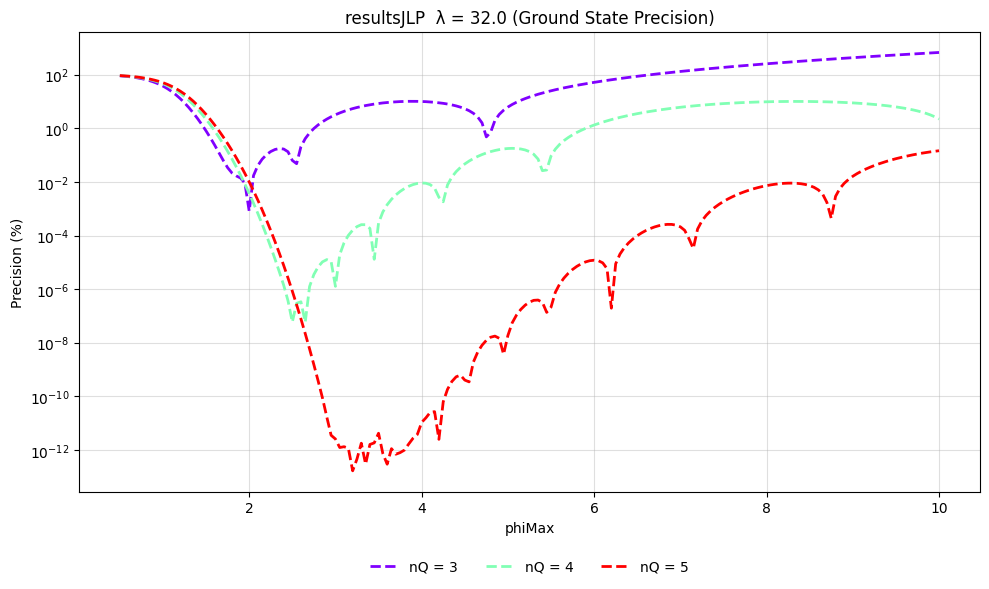

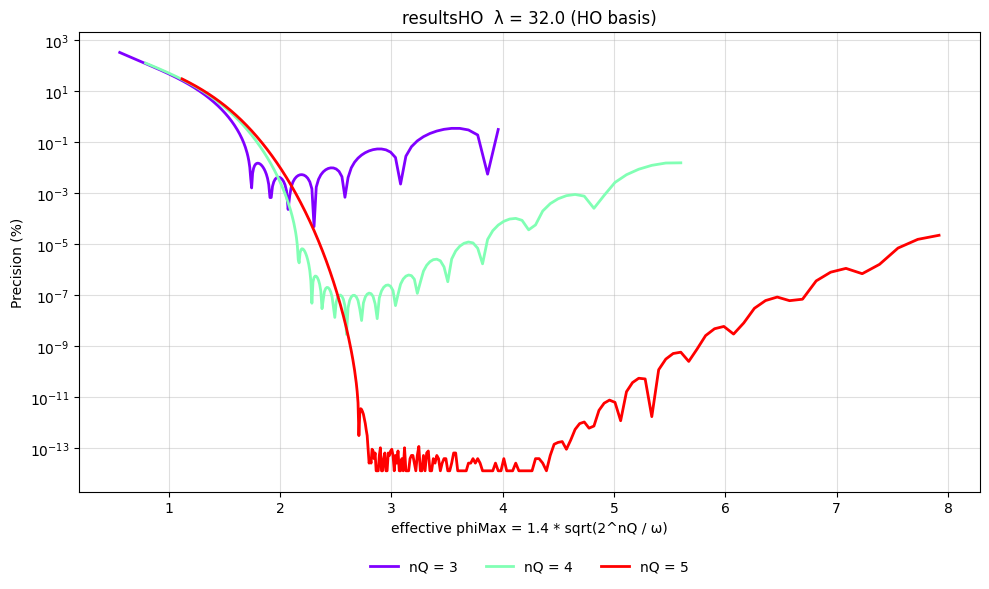

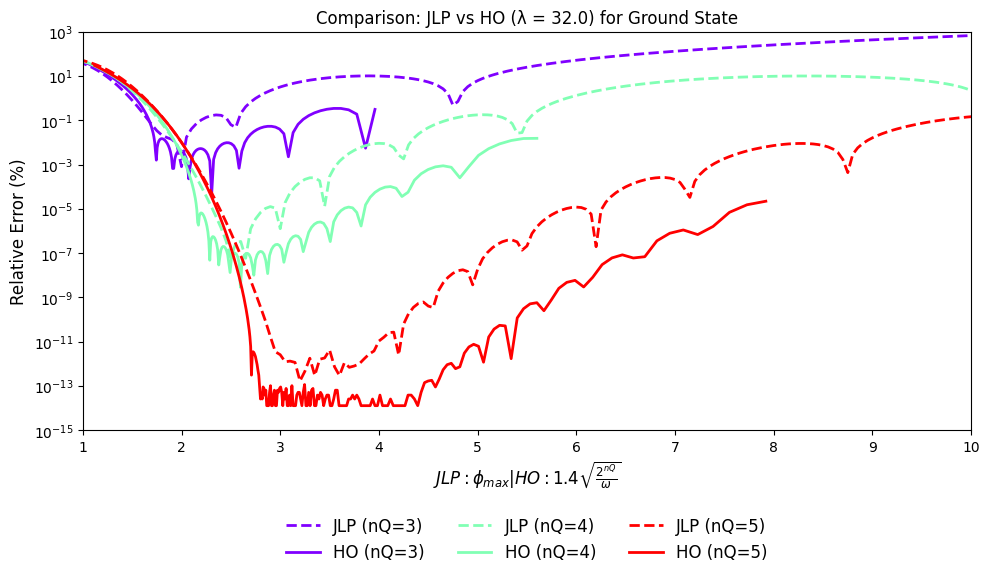

In [ ]:
# -*- coding: utf-8 -*-
"""
JLP + HO + combined comparison plot
with the rule:
  any y <= 0  --> replaced by the smallest strictly-positive y in that curve.
"""

fontsize = 12

from __future__ import annotations
import numpy as np
import matplotlib.pyplot as plt

try:
    from scipy.linalg import eigh  # Hermitian eigensolver
except Exception:
    eigh = None


# -------------------------
# Utilities
# -------------------------
def hermitise(H: np.ndarray) -> np.ndarray:
    return 0.5 * (H + H.conj().T)


def ground_state_energy(H: np.ndarray) -> float:
    """Smallest eigenvalue of Hermitian H."""
    if eigh is not None:
        w = eigh(H, eigvals_only=True)
        return float(np.real(w[0]))
    w = np.linalg.eigvalsh(H)
    return float(np.real(w[0]))


def clamp_nonpositive_to_min_positive(y: np.ndarray) -> np.ndarray:
    """
    Replace all y <= 0 with the smallest strictly-positive value in y.
    If there are no positive values, raises ValueError.
    """
    y = np.asarray(y, dtype=float)
    pos = y[y > 0]
    if pos.size == 0:
        raise ValueError("No strictly-positive values found; cannot clamp y<=0.")
    min_pos = pos.min()
    return np.where(y <= 0, min_pos, y)


# -------------------------
# JLP Hamiltonian (field basis + Fourier transform)
# -------------------------
def hamiltonian_jlp(ns: int, phi_max: float, lam: float) -> tuple[np.ndarray, np.ndarray]:
    if ns < 2:
        raise ValueError("ns must be >= 2")

    delta_phi = 2.0 * phi_max / (ns - 1)
    beta = np.arange(ns, dtype=float)
    phi = -phi_max + beta * delta_phi
    phi2 = np.diag(phi**2)

    kmax = np.pi / delta_phi
    delta_k = 2.0 * np.pi / (delta_phi * ns)
    betak = np.arange(ns, dtype=float)
    k = -kmax + betak * delta_k

    F = np.exp(-1j * np.outer(k, phi)) / np.sqrt(ns)
    Pik2 = np.diag(k**2)
    Piphi2 = F.conj().T @ Pik2 @ F

    H = 0.5 * (phi2 + Piphi2) + (lam / 24.0) * np.linalg.matrix_power(phi2, 2)
    H = hermitise(H)
    return H, phi


def precision_e0_jlp(ns: int, phi_max: float, lam: float, e0_ref: float) -> float:
    H, _ = hamiltonian_jlp(ns, phi_max, lam)
    e0 = ground_state_energy(H)
    return 100.0 * abs((e0 - e0_ref) / e0_ref)


def compute_results_jlp(nq_list, phi_max_values, lam: float, e0_ref: float) -> dict[int, np.ndarray]:
    results: dict[int, np.ndarray] = {}
    print(f"Computing JLP results for lambda = {lam}")
    print(f"Reference E0 = {e0_ref}")

    for nq in nq_list:
        nq = int(nq)
        ns = 2**nq
        print(f"→ Calculating for nQ = {nq} (ns = {ns})")
        rows = []
        for pm in phi_max_values:
            rows.append([float(pm), precision_e0_jlp(ns, float(pm), lam, e0_ref)])
        results[nq] = np.array(rows, dtype=float)
    return results


def plot_single_set_results_jlp(results: dict[int, np.ndarray], nq_list, lam: float, title_name="resultsJLP"):
    nq_list = [int(x) for x in nq_list]
    colors = plt.cm.rainbow(np.linspace(0, 1, len(nq_list)))

    fig, ax = plt.subplots(figsize=(10, 6))
    for c, nq in zip(colors, nq_list):
        data = results[nq]
        x = data[:, 0]
        y = clamp_nonpositive_to_min_positive(data[:, 1])
        ax.plot(x, y, linestyle="--", linewidth=2, color=c, label=f"nQ = {nq}")

    ax.set_yscale("log")
    ax.grid(True, which="both", alpha=0.4)
    ax.set_xlabel("phiMax")
    ax.set_ylabel("Precision (%)")
    ax.set_title(f"{title_name}  λ = {lam} (Ground State Precision)")
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=len(nq_list), frameon=False)
    fig.tight_layout()
    return fig, ax


# -------------------------
# HO basis Hamiltonian
# -------------------------
def ladder_ops(ns: int) -> tuple[np.ndarray, np.ndarray]:
    a = np.zeros((ns, ns), dtype=complex)
    for m in range(ns - 1):
        a[m, m + 1] = np.sqrt(m + 1.0)
    ad = a.conj().T
    return a, ad


def hamiltonian_ho(ns: int, omega: float, lam: float) -> np.ndarray:
    a, ad = ladder_ops(ns)
    phi = (a + ad) / np.sqrt(2.0 * omega)
    pi = 1j * np.sqrt(omega / 2.0) * (ad - a)
    H = 0.5 * (pi @ pi + phi @ phi) + (lam / 24.0) * np.linalg.matrix_power(phi, 4)
    return hermitise(H)


def precision_e0_ho(ns: int, omega: float, lam: float, e0_ref: float) -> float:
    H = hamiltonian_ho(ns, omega, lam)
    e0 = ground_state_energy(H)
    return 100.0 * abs((e0 - e0_ref) / e0_ref)


def compute_results_ho(nq_list, omega_list, lam: float, e0_ref: float) -> dict[int, np.ndarray]:
    results: dict[int, np.ndarray] = {}
    print(f"Computing HO results for lambda = {lam}")
    print(f"Reference E0 = {e0_ref}")

    for nq in nq_list:
        nq = int(nq)
        ns = 2**nq
        print(f"→ Calculating for nQ = {nq} (ns = {ns})")
        rows = []
        for w in omega_list:
            rows.append([float(w), precision_e0_ho(ns, float(w), lam, e0_ref)])
        results[nq] = np.array(rows, dtype=float)
    return results


def plot_single_set_results_ho(results_ho: dict[int, np.ndarray], nq_list, lam: float, scalar: float = 1.4, title_name="resultsHO"):
    nq_list = [int(x) for x in nq_list]
    colors = plt.cm.rainbow(np.linspace(0, 1, len(nq_list)))

    fig, ax = plt.subplots(figsize=(10, 6))
    for c, nq in zip(colors, nq_list):
        data = results_ho[nq]
        omega = np.maximum(data[:, 0], np.finfo(float).tiny)  # keep ω>0
        xeff = scalar * np.sqrt((2.0 ** nq) / omega)
        y = clamp_nonpositive_to_min_positive(data[:, 1])
        ax.plot(xeff, y, linestyle="-", linewidth=2, color=c, label=f"nQ = {nq}")

    ax.set_yscale("log")
    ax.grid(True, which="both", alpha=0.4)
    ax.set_xlabel(f"effective phiMax = {scalar} * sqrt(2^nQ / ω)")
    ax.set_ylabel("Precision (%)")
    ax.set_title(f"{title_name}  λ = {lam} (HO basis)")
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=len(nq_list), frameon=False)
    fig.tight_layout()
    return fig, ax


# -------------------------
# Comparison plot: JLP dashed vs HO solid (same colour per nQ)
# -------------------------
def compare_results_simple(results_jlp: dict[int, np.ndarray],
                           results_ho: dict[int, np.ndarray],
                           nq_list,
                           lam: float,
                           scalar: float = 1.4,
                           xlim=(1.0, 10.0),
                           ylim=(1e-15, 1e3)):
    nq_list = [int(x) for x in nq_list]
    colors = plt.cm.rainbow(np.linspace(0, 1, len(nq_list)))

    fig, ax = plt.subplots(figsize=(10, 6))
    for c, nq in zip(colors, nq_list):
        dj = results_jlp[nq]
        xj = dj[:, 0]
        yj = clamp_nonpositive_to_min_positive(dj[:, 1])
        ax.plot(xj, yj, linestyle="--", linewidth=2, color=c, label=f"JLP (nQ={nq})")

        dh = results_ho[nq]
        omega = np.maximum(dh[:, 0], np.finfo(float).tiny)
        xh = scalar * np.sqrt((2.0 ** nq) / omega)
        yh = clamp_nonpositive_to_min_positive(dh[:, 1])
        ax.plot(xh, yh, linestyle="-", linewidth=2, color=c, label=f"HO (nQ={nq})")

    ax.set_yscale("log")
    ax.set_xlabel(r"$JLP: \phi_{max}  |    HO: 1.4 \sqrt{\frac{2^{nQ}}{ω}}$", fontsize = 12)
    ax.set_ylabel("Relative Error (%)", fontsize = 12)
    ax.set_title(f"Comparison: JLP vs HO (λ = {lam}) for Ground State", fontsize = 12)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=3, frameon=False, fontsize =12)
    fig.tight_layout()
    return fig, ax


# -------------------------
# Driver
# -------------------------
if __name__ == "__main__":
    lam = 32.0
    nq_list = [3, 4, 5]
    e0_ref = 0.8597426904455090

    phi_max_values = np.arange(0.5, 10.0 + 1e-12, 0.05)
    omega_list = np.arange(1.0, 50.0 + 1e-12, 0.05)

    results_jlp = compute_results_jlp(nq_list, phi_max_values, lam, e0_ref)
    results_ho = compute_results_ho(nq_list, omega_list, lam, e0_ref)

    # Individual plots
    plot_single_set_results_jlp(results_jlp, nq_list, lam)
    plot_single_set_results_ho(results_ho, nq_list, lam, scalar=1.4)

    # Combined comparison plot
    compare_results_simple(results_jlp, results_ho, nq_list, lam, scalar=1.4)

    plt.show()